In [1]:
from impact import Impact

from distgen import Generator

import numpy as np
import os 

ROOT = os.environ['LCLS_LATTICE']

In [2]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rcParams['figure.figsize'] = (8,4)

In [3]:
ifile = os.path.join(ROOT, 'impact/models/cu_inj/ImpactT.yaml')
gfile = os.path.join(ROOT, 'distgen/models/cu_inj/distgen.yaml')
assert os.path.exists(ifile)
assert os.path.exists(gfile)


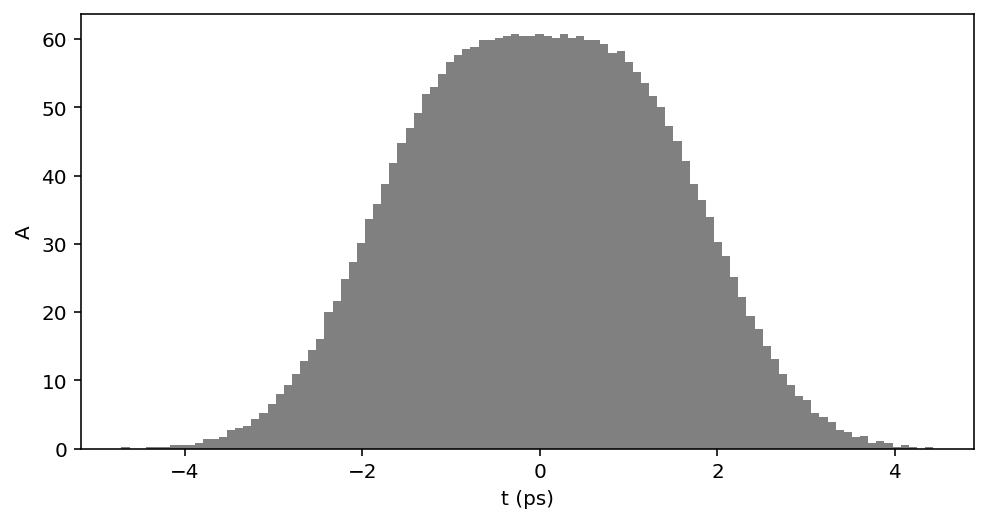

In [9]:
G = Generator(gfile)
G['n_particle'] = 10000
G.run()
P0 = G.particles
P0.plot('t')

In [10]:
P0

<ParticleGroup with 10000 particles at 0x7fc63d551150>

CPU times: user 3.17 s, sys: 727 ms, total: 3.9 s
Wall time: 9min 26s


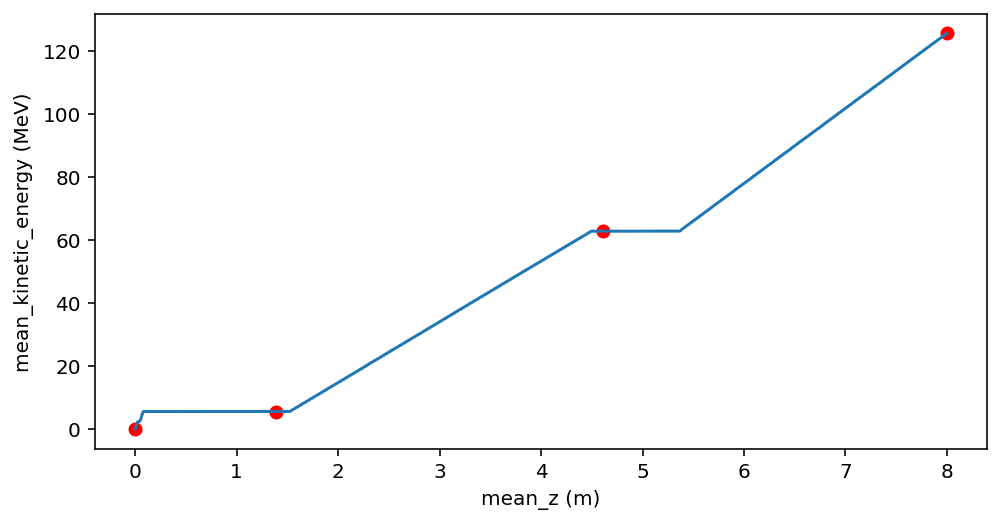

In [11]:
%%time
I = Impact.from_yaml(ifile)
I.configure()
I.initial_particles = P0
I.total_charge=0
I.stop=8
I.run()
I.plot('mean_kinetic_energy')

# Parallel run

In [ ]:
G = Generator(gfile)
G['n_particle'] = 2000
G.run()
P0 = G.particles
P0.plot('t')

In [ ]:
?Impact

In [ ]:
I = Impact(input_file=ifile, initial_particles = P0, verbose=False, use_tempdir=False, workdir='/Users/chrisonian/Scratch/temp')

# Make new elements
def new_write_beam(s, i, sample_frequency=1):
    if i in [40, 50]:
        print('Warning: will overwrite standard output files')
    ele = {'type':'write_beam', 'sample_frequency':sample_frequency}
    ele['filename'] = 'fort.'+str(i)
    ele['name'] = 'write_beam_'+str(i)
    ele['s'] = s
    return ele
def new_write_beams(slist, istart, sample_frequency=1):
    eles = []
    if len(slist) > 100:
        print('Warning: the maximum number of phase-space files which can be output is 100.')
    i = istart
    for s in slist:
        ele = new_write_beam(s, i, sample_frequency)
        eles.append(ele)
        i += 1
    return eles
slist = np.linspace(0.001,4, 99)
neweles = new_write_beams(slist, 100)

In [ ]:
# Change some things
I.header['Nx'] = 32
I.header['Ny'] = 32
I.header['Nz'] = 32
I.header['Dt'] = 5e-13
I.stop = 15

# Set parallel domain
I.header['Npcol'] = 1
I.header['Nprow'] = 4

# Turn on MPI switches
I.use_mpi=True
I.impact_bin = '$IMPACTT_MPI_BIN'
I.mpi_exe = 'mpirun' 

I.write_input()